# PCG Murmur Detection — Colab end-to-end

Notebook này **import trực tiếp code trong project**, không copy lại các hàm DSP. Cell setup sẽ clone repository GitHub rồi cài package ở chế độ editable.

Flow: `install → import project → download full CirCor → audit → baseline → 24-run matrix → robustness → plots → model bundle → inference`.

## Step 0 — Chuẩn bị code

Colab clone repository, thêm `src/` vào Python path và cài package `pcg_dsp`. Từ đây notebook gọi trực tiếp code project, không viết lại các hàm DSP.

In [14]:
# 1) Clone repository và cài package của project
from pathlib import Path
import subprocess, sys

REPO_URL = 'https://github.com/nstung463/pcg_murmur_dsp.git'
LOCAL_PROJECT_DIR = Path.cwd()
PROJECT_CANDIDATES = [LOCAL_PROJECT_DIR, *LOCAL_PROJECT_DIR.parents]
PROJECT_CANDIDATES += [child for child in LOCAL_PROJECT_DIR.iterdir() if child.is_dir()]
PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if (p / 'src' / 'pcg_dsp').exists()), Path('/content/pcg_murmur_dsp'))
if not (PROJECT_DIR / 'src' / 'pcg_dsp').exists():
    subprocess.run(['git', 'clone', REPO_URL, str(PROJECT_DIR)], check=True)

SRC_DIR = PROJECT_DIR / 'src'
if not (SRC_DIR / 'pcg_dsp').exists():
    raise RuntimeError(f'Không tìm thấy source package: {SRC_DIR / "pcg_dsp"}')
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
# Local Windows run đã có src/ trên sys.path; tránh editable install trong path có tiếng Việt.
if PROJECT_DIR == Path('/content/pcg_murmur_dsp'):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(PROJECT_DIR)], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib', 'seaborn', 'tqdm', 'requests'], check=True)
print('Imported project from:', PROJECT_DIR)
print('Python source path:', SRC_DIR)

Imported project from: f:\2. Thạc sĩ\DSP\pcg_murmur_dsp
Python source path: f:\2. Thạc sĩ\DSP\pcg_murmur_dsp\src


## Step 1 — Dataset: WAV là một dãy số

File WAV chứa các samples biên độ theo thời gian. Cell dưới tải metadata và recordings từ CirCor. `FAST_MODE=True` chỉ lấy 100 bệnh nhân để kiểm tra nhanh; `False` chạy full cohort.

In [15]:
# 2) Download full CirCor training data
import shutil, subprocess
LOCAL_DATA_DIR = PROJECT_DIR / 'data' / 'circor-heart-sound' / '1.0.3' / 'training_data'
COLAB_DATA_DIR = Path('/content/data/circor-heart-sound/1.0.3/training_data')
DATA_DIR = LOCAL_DATA_DIR if LOCAL_DATA_DIR.exists() else COLAB_DATA_DIR
OUTPUT_DIR = PROJECT_DIR / 'artifacts' / 'notebook_flow' if LOCAL_DATA_DIR.exists() else Path('/content/pcg_dsp_outputs')
DATA_DIR.mkdir(parents=True, exist_ok=True); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# False = full cohort; True = 100 patients để test nhanh trước
FAST_MODE = True
MAX_PATIENTS = 100 if FAST_MODE else None
RUN_TRAINING = False
RUN_MATRIX = False
RUN_ROBUSTNESS = False

def missing_wav_references(data_dir):
    missing = []
    for patient_file in data_dir.glob('*.txt'):
        lines = patient_file.read_text(encoding='utf-8', errors='replace').splitlines()
        for line in lines[1:]:
            fields = line.split()
            if len(fields) >= 3 and not fields[0].startswith('#'):
                wav_path = data_dir / fields[2]
                if not wav_path.exists():
                    missing.append(wav_path.name)
    return sorted(set(missing))

missing_wavs = missing_wav_references(DATA_DIR)
if not list(DATA_DIR.glob('*.txt')) or missing_wavs:
    if os.name == 'nt':
        raise FileNotFoundError(
            f'Dataset not found at {LOCAL_DATA_DIR}. Open the notebook from the project, or set DATA_DIR manually to the training_data folder.'
        )
    if shutil.which('aws') is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'awscli'], check=True)
    subprocess.run([
        'aws', 's3', 'sync', '--no-sign-request',
        's3://physionet-open/circor-heart-sound/1.0.3/training_data',
        str(DATA_DIR), '--only-show-errors'
    ], check=True)

print('Patient files:', len(list(DATA_DIR.glob('*.txt'))))
missing_wavs = missing_wav_references(DATA_DIR)
print('Missing WAV references:', len(missing_wavs))
if missing_wavs:
    print('First missing files:', missing_wavs[:10])
    raise RuntimeError('Dataset download is incomplete; re-run this cell to resume the S3 sync.')
if not list(DATA_DIR.glob('*.txt')):
    raise RuntimeError('Download chưa tạo file *.txt; thử chạy lại cell hoặc dùng ZIP của PhysioNet.')

Patient files: 942
Missing WAV references: 0


## Step 2 — Import đúng code project

Các module được dùng là `pcg_dsp.io`, `pcg_dsp.dsp`, `pcg_dsp.pipeline` và `pcg_dsp.service`. Đây cũng chính là code được app Streamlit dùng.

In [16]:
# 3) Import đúng các module của project
import copy, json, yaml, joblib, os, sys
if str(PROJECT_DIR / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR / 'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from tqdm.auto import tqdm
from IPython.display import display

from pcg_dsp.io import build_manifest, iter_patients, load_wav
from pcg_dsp.dsp import apply_filter, design_filter, stft_matrix, quantize, resample_signal, segment_signal, feature_vector
from pcg_dsp.pipeline import make_patient_table, train_evaluate, patient_split
from pcg_dsp.service import analyze_recording, load_model_bundle

BASE_CONFIG = yaml.safe_load((PROJECT_DIR / 'configs' / 'default.yaml').read_text(encoding='utf-8'))
BASE_CONFIG['data']['root'] = str(DATA_DIR)
BASE_CONFIG['data']['max_patients'] = MAX_PATIENTS
BASE_CONFIG['data']['skip_invalid_patients'] = True
BASE_CONFIG['data']['n_jobs'] = max(1, min(4, (os.cpu_count() or 2) - 1))
print('Project package import OK')
print('Feature workers:', BASE_CONFIG['data']['n_jobs'])

Project package import OK
Feature workers: 4


## Step 3 — Audit trước khi train

Ta đếm bệnh nhân, recording, label và sample rate để biết input thật sự có gì trước khi chạy model.

In [17]:
# 4) Audit data: counts, labels, sample rates
manifest = build_manifest(DATA_DIR, include_unknown=True)
audit_paths = manifest['wav_path'].sample(n=min(100, len(manifest)), random_state=42).tolist() if len(manifest) else []
rates = [load_wav(path)[0] for path in tqdm(audit_paths, desc='checking sample rates')]
print(f"Patients: {manifest.patient_id.nunique():,}")
print(f"Recordings: {len(manifest):,}")
print('Sample rates:', pd.Series(rates).value_counts().sort_index().to_dict())
display(manifest.groupby('label').agg(patients=('patient_id','nunique'), recordings=('recording_id','count')))
manifest.to_csv(OUTPUT_DIR / 'manifest.csv', index=False)

checking sample rates: 100%|██████████| 100/100 [00:00<00:00, 2006.33it/s]

Patients: 942
Recordings: 3,163
Sample rates: {4000: 100}


,patients,recordings
label,,
Absent,695,2391
Present,179,616
Unknown,68,156


## Lecture cross-reference — công thức nào đang được áp dụng ở đâu?

Cell này nối trực tiếp pipeline của project với các slide bài giảng DSP. Số slide bên dưới là số in ở chân slide trong PDF (không phải số cell notebook).

| Bước trong project | Công thức / ý tưởng DSP | Áp dụng trong code | Tham chiếu bài giảng |
|---|---|---|---|
| **WAV → discrete-time signal** | \(x[n] = x_a(nT_s)\), \(T_s = 1/f_s\) | `load_wav()` đọc PCM thành mảng `x[n]` | **Lecture 1**, *Discrete-Time Signals and Systems*, **Slide 5–7** |
| **Resampling** | Đổi `T_s`/`f_s`; để không alias cần giới hạn băng trước khi giảm tốc độ lấy mẫu | `resample_signal(signal, fs, target_fs)` | **Lecture 2**, *Sampling & Reconstruction*, **Slide 4, 6–8** (sampling period, phổ lặp, Nyquist/aliasing) |
| **Nyquist check** | \(f_s \ge 2f_{max}\) (hay \(\Omega_s \ge 2\Omega_N\)) | `target_fs = 1000` Hz, band quan tâm đến 400 Hz nên \(1000 \ge 2\cdot400\) | **Lecture 2, Slide 7** |
| **Quantization** | \(L = 2^B\); lượng tử hoá làm tròn biên độ; sai số \(e[n] = x[n] - x_q[n]\), mức cực đại lý tưởng khoảng \(\Delta/2\) | `quantize(signal, bits=16/8)` | **Lecture 2, Slide 23–25** (mã nhị phân và quantization error); **Lecture 7, Slide 54** (ảnh hưởng lượng tử hệ số) |
| **Band-pass filter** | \(Y(e^{j\omega}) = H(e^{j\omega})X(e^{j\omega})\); lý tưởng: \(H_{bp}(e^{j\omega}) = 1\) trong \([\omega_1,\omega_2]\), 0 ngoài dải | `design_filter(..., "butterworth", 25, 400, ...)` + `apply_filter()` | **Lecture 4**, *Frequency Analysis of Signals & Systems*, **Slide 4 và 7** |
| **FIR/IIR implementation** | \(y[n] = h[n]*x[n]\) (FIR); IIR có hồi tiếp theo phương trình sai phân | Butterworth được thực thi dạng SOS/IIR bởi SciPy | **Lecture 7**, *Implementation of Discrete-Time Systems*, **Slide 23–32 (IIR)** và **Slide 43–52 (FIR)** |
| **Windowing / segmentation** | \(x_m[n] = x[n+mH]w[n]\), với window dài \(N\) và hop \(H\) | `segment_signal(..., seconds=3, hop_seconds=1.5)` | Đây là bước triển khai hữu hạn thời gian của project; liên hệ **Lecture 1, Slide 5–10** (sequence rời rạc) và **Lecture 5, Slide 32–36** (finite-length sequence/DFT) |
| **DFT / FFT feature** | \(X[k] = \sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}\); \(x[n] = (1/N)\sum_k X[k]e^{j2\pi kn/N}\) | `np.fft.rfft()` trong `_fft_features()` | **Lecture 5**, *Discrete Fourier Transform*, **Slide 35–36** |
| **FFT efficiency** | FFT phân rã DFT theo even/odd; độ phức tạp từ \(O(N^2)\) xuống \(O(N\log_2 N)\) | Project gọi thư viện `np.fft`, không tự viết butterfly | **Lecture 6**, *Fast Fourier Transform*, **Slide 4–14**, đặc biệt **Slide 13** |
| **PSD / STFT / MFCC** | PSD/STFT là các biểu diễn phổ dùng cho feature; STFT thường viết \(X(m,k)=\sum_n x[n]w[n-mH]e^{-j2\pi kn/N}\) | `signal.welch()`, `stft_matrix()`, `librosa.feature.mfcc()` | Không có slide MFCC/PSD/STFT tương ứng trong 7 PDF core đã cung cấp; notebook đánh dấu đây là **phần mở rộng xử lý audio của đồ án**, không gán nhầm là công thức slide core |
| **SVM + metrics** | ML nhận vector feature, không phải nội dung DSP; đánh giá bằng Accuracy/Precision/Recall/F1 và confusion matrix | `make_model()` + `train_evaluate()` | Theo đề tài/experimental protocol của project; tách riêng khỏi phần DSP trong bài giảng |

### Cách đọc các công thức trong flow

1. `load_wav()` tạo chuỗi rời rạc \(x[n]\) từ PCM (Lecture 1).
2. Resample/quantize thay đổi lưới thời gian và mức biên độ (Lecture 2).
3. Filter áp dụng đáp ứng tần số `H` để tạo `y[n]` (Lecture 4); cấu trúc thực thi là IIR/FIR (Lecture 7).
4. Mỗi window hữu hạn được biến đổi sang miền tần số bằng DFT/FFT (Lecture 5–6), rồi mới gom thành feature vector.
5. SVM chỉ là tầng phân loại phía sau DSP. Vì vậy các ablation `filter=None`, `quantization_bits`, `target_fs`, `feature_mode` đo **ảnh hưởng của từng khối DSP lên cùng một SVM protocol**.

> Lưu ý: `filter=None` nghĩa là **bỏ band-pass**, không phải “SVM trên raw waveform”. Pipeline vẫn resample, quantize, segment và extract feature để phép so sánh chỉ thay đổi đúng một yếu tố.

## Deep dive A — File WAV thực chất là gì?

WAV có một phần header (sample rate, số channel, bit depth) và phần dữ liệu PCM. Phần PCM là dãy số biên độ:

`x[0], x[1], x[2], ...`

`load_wav()` của project chuyển dữ liệu integer về `float32`, chuẩn hóa gần `[-1, 1]`, và nếu stereo thì lấy trung bình hai channel thành mono.

**Lecture note cho cell kế tiếp — Lecture 1, slide 5–7**

Code bên dưới đang biến tín hiệu analog đã lấy mẫu thành chuỗi rời rạc:

$$x[n] = x_a(nT_s), \qquad f_s = 1/T_s$$

Trong đó `T_s` là sampling period.

`wavfile.read()` cho ta header + PCM thô; `load_wav()` thực hiện bước chuẩn hóa để chuỗi `x[n]` có thể đi qua các khối DSP tiếp theo. Vì vậy biểu đồ dưới đây là biểu diễn **biên độ theo từng chỉ số n**, không phải ảnh spectrogram.

In [36]:
pcm

array([   0,   33,  302, ..., -357,  -76,  513],
      shape=(41152,), dtype=int16)

In [38]:
loaded_fs

4000

File: 13918_AV.wav
Header sample rate: 4000 Hz
Header dtype: int16
Header shape: (41152,)
First 12 PCM values: [    0    33   302   144 -1089  -279   576  -266   423   837   439   745]
After load_wav dtype: float32
After load_wav range: -1.0 0.999969482421875
Duration: 10.29 seconds


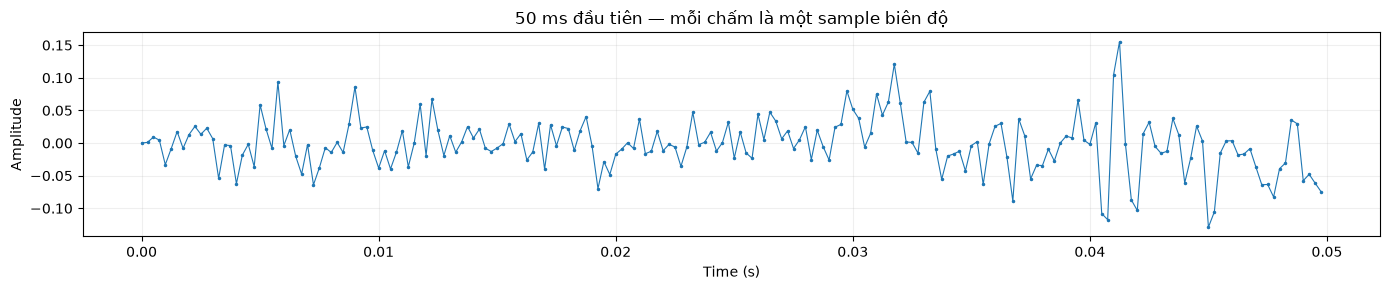

In [18]:
# Deep dive A — xem header và dãy số PCM của một WAV
from scipy.io import wavfile

deep_sample = Path(manifest.iloc[0].wav_path)
header_fs, pcm = wavfile.read(deep_sample)
loaded_fs, loaded_signal = load_wav(deep_sample)

print("File:", deep_sample.name)
print("Header sample rate:", header_fs, "Hz")
print("Header dtype:", pcm.dtype)
print("Header shape:", pcm.shape)
print("First 12 PCM values:", pcm[:12])
print("After load_wav dtype:", loaded_signal.dtype)
print("After load_wav range:", float(loaded_signal.min()), float(loaded_signal.max()))
print("Duration:", round(len(loaded_signal) / loaded_fs, 2), "seconds")

view_n = min(len(loaded_signal), max(1, int(.05 * loaded_fs)))
plt.figure(figsize=(14, 3))
plt.plot(np.arange(view_n) / loaded_fs, loaded_signal[:view_n], marker=".", ms=3, lw=.8)
plt.title("50 ms đầu tiên — mỗi chấm là một sample biên độ")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=.2)
plt.tight_layout()
plt.show()

## Deep dive B — Layer 1: Resample

Nếu WAV gốc là 4 kHz thì có 4.000 samples mỗi giây. Resample về 1 kHz làm giảm mật độ samples xuống còn 1.000 mỗi giây; thời lượng và nội dung thời gian vẫn giữ nguyên.

Ví dụ: đoạn 3 giây giảm từ 12.000 samples xuống 3.000 samples.

**Lecture note cho cell kế tiếp — Lecture 2, slide 4, 6–8**

Resampling thay đổi `T_s` và `f_s`. Khi giảm sampling rate, điều kiện Nyquist cần kiểm tra là:

$$f_s \ge 2f_{max}$$

Ở pipeline này `target_fs = 1000 Hz`, còn band quan tâm kết thúc ở `400 Hz`, nên `1000 >= 2·400`. Hàm `resample_signal()` dùng nội suy/lọc của SciPy để đổi số mẫu nhưng giữ gần nguyên thời lượng. Lecture 2 slide 8 minh họa aliasing nếu điều kiện này bị vi phạm.

Before: 41152 samples at 4000 Hz
After : 10288 samples at 1000 Hz
Duration before/after: 10.288 10.288 seconds


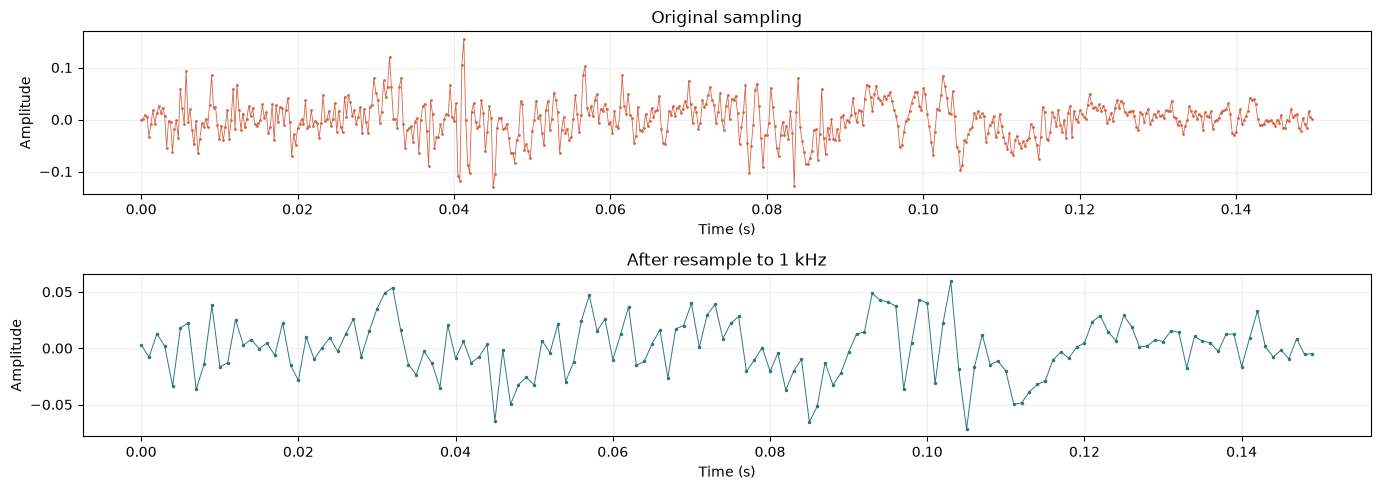

In [19]:
# Deep dive B — so sánh trước/sau resample
target_fs = 1000
resampled_deep = resample_signal(loaded_signal, loaded_fs, target_fs)
print("Before:", len(loaded_signal), "samples at", loaded_fs, "Hz")
print("After :", len(resampled_deep), "samples at", target_fs, "Hz")
print("Duration before/after:", round(len(loaded_signal)/loaded_fs, 3), round(len(resampled_deep)/target_fs, 3), "seconds")

seconds = min(.15, len(loaded_signal)/loaded_fs)
n_before = int(seconds * loaded_fs)
n_after = int(seconds * target_fs)
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].plot(np.arange(n_before)/loaded_fs, loaded_signal[:n_before], color="#D96445", marker=".", ms=2, lw=.6)
axes[0].set_title("Original sampling")
axes[1].plot(np.arange(n_after)/target_fs, resampled_deep[:n_after], color="#2B7A78", marker=".", ms=3, lw=.7)
axes[1].set_title("After resample to 1 kHz")
for ax in axes:
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude"); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

## Deep dive C — Layer 2: Quantization

Quantization làm tròn biên độ về một số mức hữu hạn:

- 16-bit: tối đa `2^16` mức;
- 8-bit: tối đa `2^8` mức.

Bit depth thấp hơn nghĩa là các thay đổi biên độ nhỏ có thể bị làm tròn mất.

**Lecture note cho cell kế tiếp — Lecture 2, slide 23–25**

Với `B` bit, số mức lý thuyết là:

$$L = 2^B$$

Nếu bước lượng tử là `Δ` thì sai số:

$$e[n] = x[n] - x_q[n], \qquad |e[n]| \le \Delta/2$$

Cell này cố ý chạy hai nhánh `B=16` và `B=8`, sau đó đo số mức thực tế và sai khác trung bình. Đây là **ablation của lượng tử hóa tín hiệu**, liên hệ trực tiếp với phần quantization error ở slide 25; slide 54 Lecture 7 là quantization của hệ số filter, khác với phép thử này.

Theoretical levels — 16-bit: 65536 | 8-bit: 256
Observed unique values — 16-bit: 3201 | 8-bit: 104
First 12 values after 16-bit: [ 0.00306702 -0.00801098  0.01292443  0.00160217 -0.03364617  0.01811242
  0.02244604 -0.03657585 -0.01438928  0.03788817 -0.01658654 -0.01298541]
First 12 values after 8-bit : [ 0.00392163 -0.01176471  0.01176476  0.00392163 -0.03529412  0.0196079
  0.0196079  -0.03529412 -0.01176471  0.03529418 -0.01960784 -0.01176471]
Mean absolute quantization difference: 0.0019461670890450478


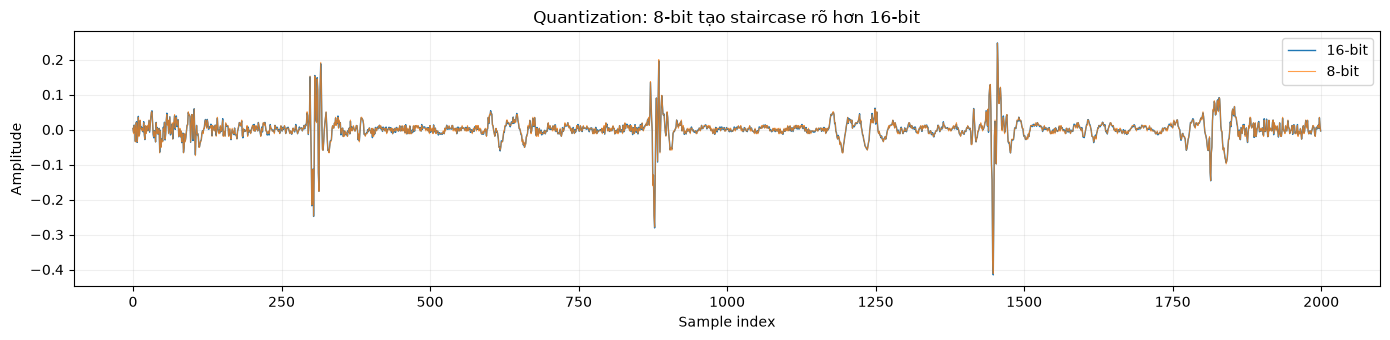

In [39]:
# Deep dive C — nhìn sai số quantization 16-bit và 8-bit
quant16 = quantize(resampled_deep, bits=16)
quant8 = quantize(resampled_deep, bits=8)
print("Theoretical levels — 16-bit:", 2**16, "| 8-bit:", 2**8)
print("Observed unique values — 16-bit:", len(np.unique(quant16)), "| 8-bit:", len(np.unique(quant8)))
print("First 12 values after 16-bit:", quant16[:12])
print("First 12 values after 8-bit :", quant8[:12])
print("Mean absolute quantization difference:", float(np.mean(np.abs(quant16 - quant8))))

n = min(len(quant16), 2000)
plt.figure(figsize=(14, 3.5))
plt.plot(quant16[:n], label="16-bit", lw=1)
plt.plot(quant8[:n], label="8-bit", lw=.8, alpha=.75)
plt.title("Quantization: 8-bit tạo staircase rõ hơn 16-bit")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

## Deep dive D — Layer 3: Band-pass filter

Filter giống như một chiếc rây tần số:

- loại phần dưới 25 Hz: drift/baseline;
- giữ phần 25–400 Hz: vùng quan tâm của heart sound/murmur;
- giảm phần trên 400 Hz: nhiễu cao tần.

Đây vẫn là waveform 1D, chỉ là waveform đã được làm sạch theo miền tần số.

**Lecture note cho cell kế tiếp — Lecture 4, slide 4 và 7; Lecture 7, slide 23–32**

Với hệ LTI:

$$Y(e^{j\omega}) = H(e^{j\omega})X(e^{j\omega})$$

Bộ lọc band-pass lý tưởng có `H=1` trong dải `[ω1, ω2]` và `H=0` ngoài dải. Project dùng Butterworth bậc 4 với biên 25–400 Hz; `sosfreqz()` vẽ `|H|` để ta kiểm chứng code đang giữ đúng vùng tần số nào. Butterworth là IIR/SOS implementation, nên phần cấu trúc thực thi liên hệ Lecture 7.

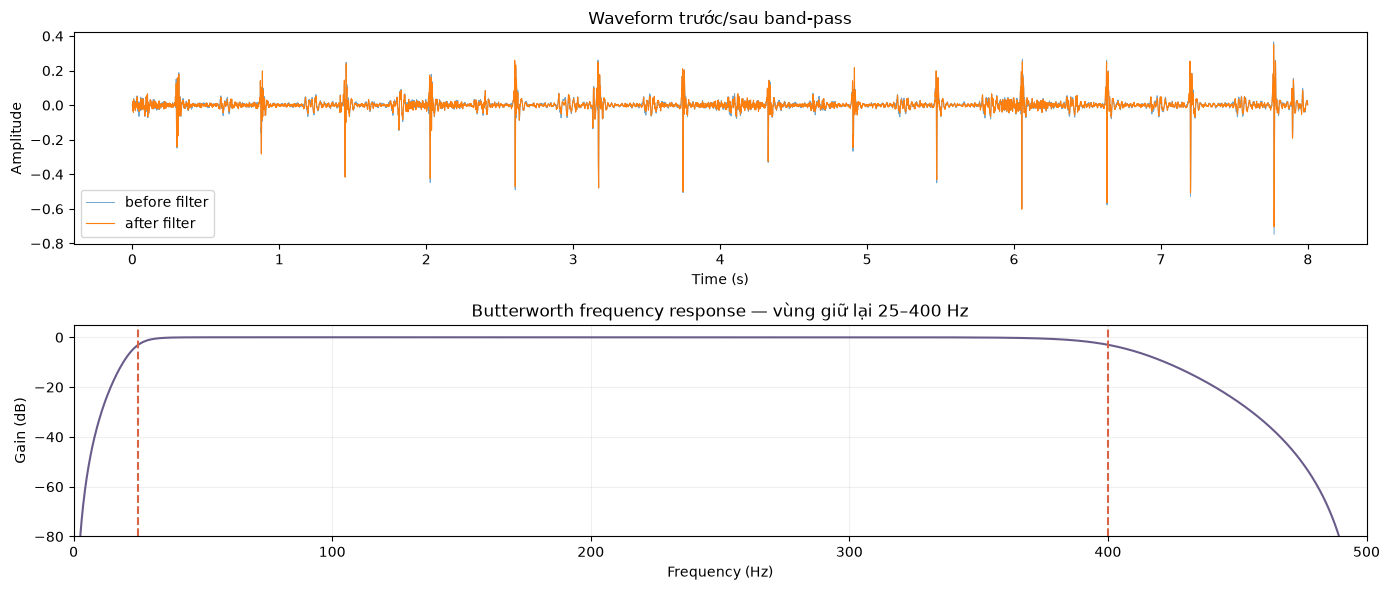

In [21]:
# Deep dive D — waveform và đáp ứng tần số của Butterworth
filter_spec_deep = design_filter(target_fs, "butterworth", 25, 400, 4, 129)
filtered_deep = apply_filter(quant16, filter_spec_deep)
_, sos_coeff = filter_spec_deep
response_freq, response = signal.sosfreqz(sos_coeff, worN=2048, fs=target_fs)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
view_n = min(len(quant16), 8 * target_fs)
axes[0].plot(np.arange(view_n)/target_fs, quant16[:view_n], label="before filter", lw=.7, alpha=.65)
axes[0].plot(np.arange(view_n)/target_fs, filtered_deep[:view_n], label="after filter", lw=.8)
axes[0].set_title("Waveform trước/sau band-pass")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Amplitude"); axes[0].legend()
axes[1].plot(response_freq, 20*np.log10(np.maximum(np.abs(response), 1e-8)), color="#6A5C8A")
axes[1].axvline(25, color="#D96445", ls="--"); axes[1].axvline(400, color="#D96445", ls="--")
axes[1].set_xlim(0, target_fs/2); axes[1].set_ylim(-80, 5)
axes[1].set_title("Butterworth frequency response — vùng giữ lại 25–400 Hz")
axes[1].set_xlabel("Frequency (Hz)"); axes[1].set_ylabel("Gain (dB)")
axes[1].grid(alpha=.2)
plt.tight_layout(); plt.show()

## Deep dive E — Layer 4: Chia thành các đoạn nhỏ

Recording dài được chia thành window 3 giây, bước nhảy 1,5 giây. Hai window liên tiếp chồng lên nhau 1,5 giây để không bỏ sót murmur nằm ở ranh giới.

**Lecture note cho cell kế tiếp — liên hệ Lecture 1, slide 5–10 và Lecture 5, slide 32–36**

Một window hữu hạn có thể viết:

$$x_m[n] = x[n + mH]w[n]$$

trong đó `N = seconds·f_s = 3000` samples và `H = hop_seconds·f_s = 1500` samples. Vì `H < N`, hai window chồng nhau 50%. Đây là cách đưa recording dài về các sequence hữu hạn để DFT/feature extraction xử lý được.

Samples per window: 3000
Number of windows: 5


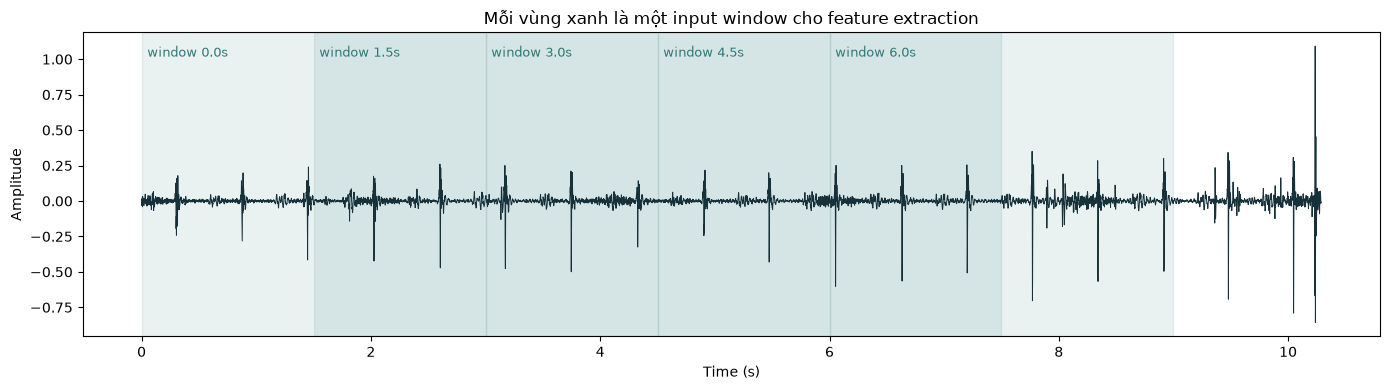

In [22]:
# Deep dive E — visualize các window 3 s / hop 1,5 s
deep_segments = segment_signal(filtered_deep, target_fs, seconds=3.0, hop_seconds=1.5)
print("Samples per window:", len(deep_segments[0]))
print("Number of windows:", len(deep_segments))
view_n = min(len(filtered_deep), 12 * target_fs)
time_axis = np.arange(view_n) / target_fs
plt.figure(figsize=(14, 4))
plt.plot(time_axis, filtered_deep[:view_n], color="#17313B", lw=.7)
for start in np.arange(0, max(0, view_n/target_fs - 3), 1.5):
    plt.axvspan(start, start+3, color="#2B7A78", alpha=.10)
    plt.text(start+.05, 0.92, f"window {start:.1f}s", transform=plt.gca().get_xaxis_transform(), fontsize=9, color="#2B7A78")
plt.title("Mỗi vùng xanh là một input window cho feature extraction")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.tight_layout(); plt.show()

## Deep dive F — Từ một window waveform thành feature vector

Với mỗi window, project tính nhiều góc nhìn:

- time domain: mean, std, RMS, skewness, kurtosis;
- FFT/PSD: peak frequency, band power, spectral entropy;
- STFT: thống kê năng lượng trên time-frequency matrix;
- MFCC: mô tả hình dạng phổ âm thanh.

Kết quả cuối cùng là một vector số nhỏ hơn rất nhiều so với 3.000 samples raw.

**Lecture note cho cell kế tiếp — Lecture 5, slide 35–36; Lecture 6, slide 4–14**

FFT magnitude trong code là phép tính nhanh của DFT:

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$$

`np.fft.rfft()` chỉ giữ nửa phổ dương của tín hiệu thực. Lecture 6 giải thích phép tách even/odd và độ phức tạp `O(N log₂N)`; project gọi thư viện FFT chuẩn, không tự viết butterfly. PSD dùng `signal.welch()` để ước lượng năng lượng phổ; STFT dùng nhiều DFT trên các frame; MFCC là feature mở rộng audio, không phải công thức xuất hiện trong 7 PDF core.

Raw window length: 3000 samples
 stats:   5 numeric features | first values = [-3.8035825e-05  3.4099579e-02  3.4099601e-02 -3.9882543e+00
  5.9657276e+01]
   psd:  16 numeric features | first values = [-3.8035825e-05  3.4099579e-02  3.4099601e-02 -3.9882543e+00
  5.9657276e+01]
  mfcc:  31 numeric features | first values = [-3.8035825e-05  3.4099579e-02  3.4099601e-02 -3.9882543e+00
  5.9657276e+01]
  stft:   9 numeric features | first values = [-3.8035825e-05  3.4099579e-02  3.4099601e-02 -3.9882543e+00
  5.9657276e+01]
hybrid:  46 numeric features | first values = [-3.8035825e-05  3.4099579e-02  3.4099601e-02 -3.9882543e+00
  5.9657276e+01]


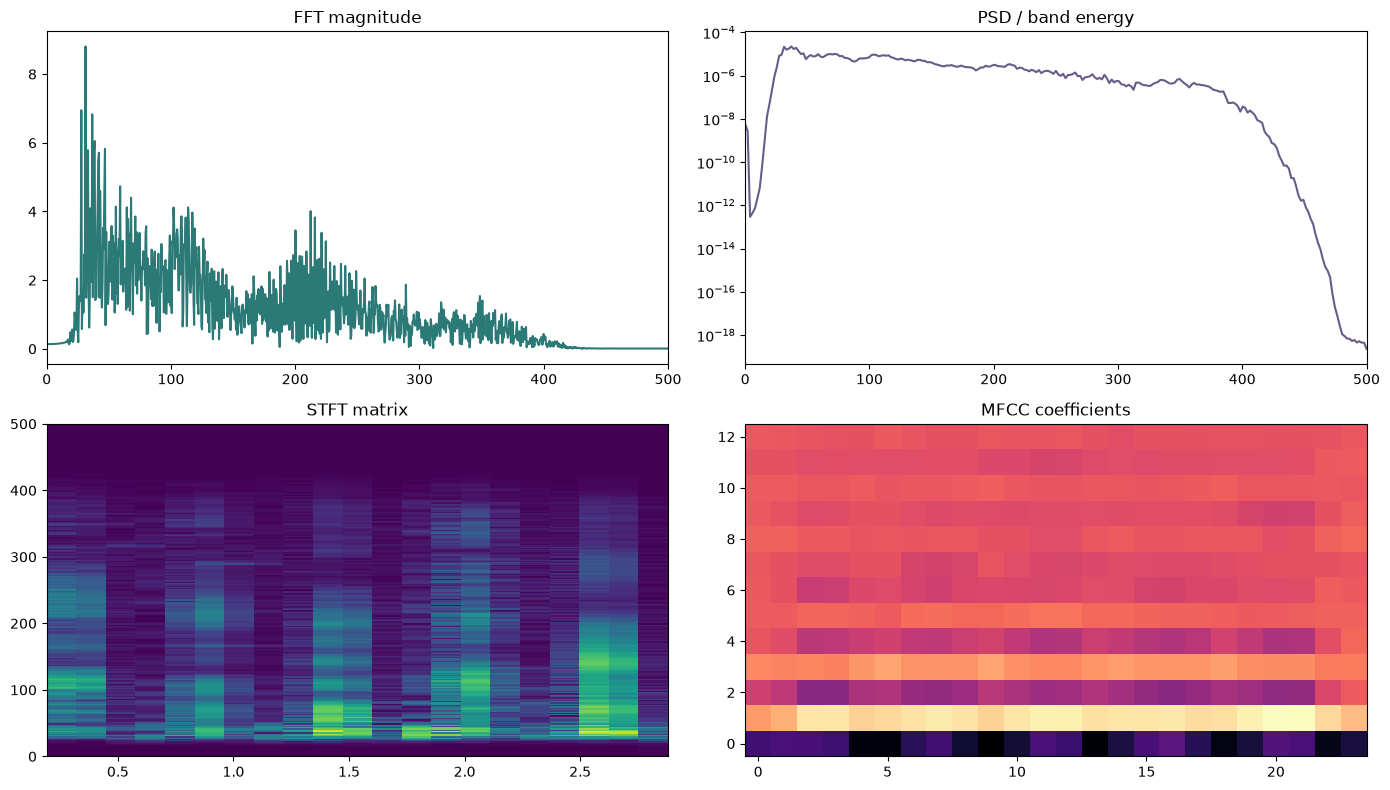

In [23]:
# Deep dive F — xem độ dài từng feature mode và các biểu diễn trung gian
feature_config_deep = {key: value for key, value in BASE_CONFIG["features"].items() if key != "mode"}
first_window = deep_segments[0]
feature_modes = ["stats", "psd", "mfcc", "stft", "hybrid"]
feature_vectors = {
    mode: feature_vector(first_window, target_fs, mode=mode, **feature_config_deep)
    for mode in feature_modes
}
print("Raw window length:", len(first_window), "samples")
for mode, vector in feature_vectors.items():
    print(f"{mode:>6}: {len(vector):>3} numeric features | first values = {vector[:5]}")

fft_freq = np.fft.rfftfreq(2048, 1/target_fs)
fft_mag = np.abs(np.fft.rfft(first_window, n=2048))
psd_freq, psd_power = signal.welch(first_window, fs=target_fs, nperseg=min(512, len(first_window)))
stft_freq, stft_time, stft_mag = stft_matrix(first_window, target_fs)
import librosa
mfcc_image = librosa.feature.mfcc(y=first_window, sr=target_fs, n_mfcc=13, n_fft=512, hop_length=128)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(fft_freq, fft_mag, color="#2B7A78"); axes[0,0].set_xlim(0, 500); axes[0,0].set_title("FFT magnitude")
axes[0,1].semilogy(psd_freq, psd_power, color="#6A5C8A"); axes[0,1].set_xlim(0, 500); axes[0,1].set_title("PSD / band energy")
axes[1,0].pcolormesh(stft_time, stft_freq, stft_mag, shading="auto", cmap="viridis"); axes[1,0].set_ylim(0, 500); axes[1,0].set_title("STFT matrix")
axes[1,1].imshow(mfcc_image, aspect="auto", origin="lower", cmap="magma"); axes[1,1].set_title("MFCC coefficients")
plt.tight_layout(); plt.show()

## Deep dive G — Từ window vector thành patient vector

Một bệnh nhân có nhiều window và nhiều vị trí nghe. Project trung bình theo hai tầng:

`windows → recording vector → patient vector`

Vì vậy model cuối cùng nhận một dòng cho mỗi bệnh nhân. Đây là điểm giúp patient-wise split có ý nghĩa và tránh leakage.

## Step 4 — Nhìn waveform trước và sau DSP

Một WAV đi qua resample, quantization và band-pass filter. Visualization kế tiếp cho thấy dãy số thay đổi ra sao.

File: 13918_AV.wav
First 12 raw samples: [ 0.          0.00100708  0.00921631  0.00439453 -0.03323364 -0.0085144
  0.01757812 -0.00811768  0.01290894  0.02554321  0.01339722  0.0227356 ]
Raw fs: 4000 Hz | target fs: 1000 Hz
Duration: 10.29 seconds


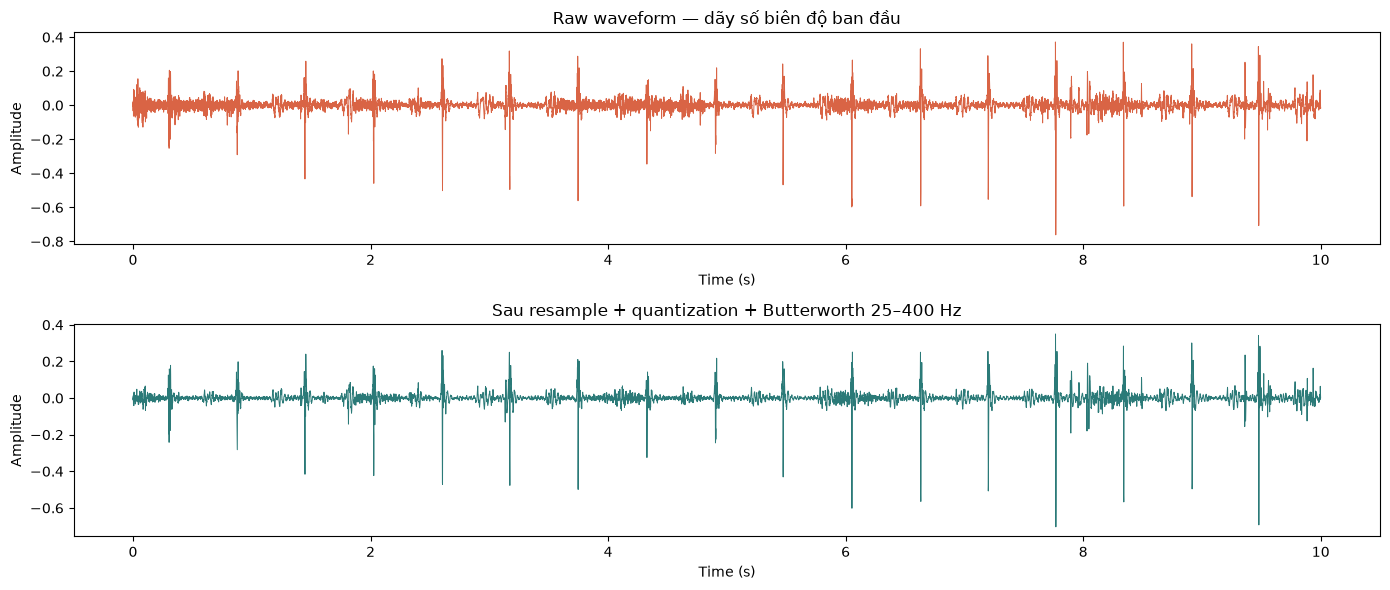

In [24]:
# Visualization A — file WAV trước và sau DSP
sample_wav = Path(manifest.iloc[0].wav_path)
fs_raw, raw = load_wav(sample_wav)
fs_target = 1000
resampled = resample_signal(raw, fs_raw, fs_target)
quantized = quantize(resampled, bits=16)
filtered = apply_filter(
    quantized,
    design_filter(fs_target, "butterworth", 25, 400, 4, 129),
)

print("File:", sample_wav.name)
print("First 12 raw samples:", raw[:12])
print("Raw fs:", fs_raw, "Hz | target fs:", fs_target, "Hz")
print("Duration:", round(len(raw) / fs_raw, 2), "seconds")

seconds = min(10, len(raw) / fs_raw)
raw_n = int(seconds * fs_raw)
filtered_n = int(seconds * fs_target)
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(np.arange(raw_n) / fs_raw, raw[:raw_n], color="#D96445", lw=.7)
axes[0].set_title("Raw waveform — dãy số biên độ ban đầu")
axes[1].plot(np.arange(filtered_n) / fs_target, filtered[:filtered_n], color="#2B7A78", lw=.7)
axes[1].set_title("Sau resample + quantization + Butterworth 25–400 Hz")
for ax in axes:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [25]:
# 5) Baseline đúng theo pipeline trong project
baseline_cfg = copy.deepcopy(BASE_CONFIG)
baseline_cfg['model']['kind'] = 'svm'
baseline_cfg['dsp']['filter'] = 'butterworth'
baseline_cfg['features']['mode'] = 'hybrid'
baseline_table = make_patient_table(DATA_DIR, baseline_cfg, MAX_PATIENTS)
if RUN_TRAINING:
    baseline_result = train_evaluate(baseline_table, baseline_cfg, OUTPUT_DIR / 'baseline_model')
    print(json.dumps(baseline_result, indent=2, default=float))
else:
    baseline_result = None
    print('RUN_TRAINING=False → feature table created; model training skipped.')

RUN_TRAINING=False → feature table created; model training skipped.


## Step 5 — Từ waveform thành feature và patient vector

Window 3 giây được biến thành feature vector. Nhiều window được trung bình thành recording vector; nhiều recording được trung bình thành patient vector.

Samples per window: 3000
Windows in sample recording: 5
Hybrid feature vector length: 46
First 10 features: [-3.8035825e-05  3.4099579e-02  3.4099601e-02 -3.9882543e+00
  5.9657276e+01  5.3058410e-01  3.3156380e-01  1.3749133e-01
  2.5665786e-04  8.5211176e-01]


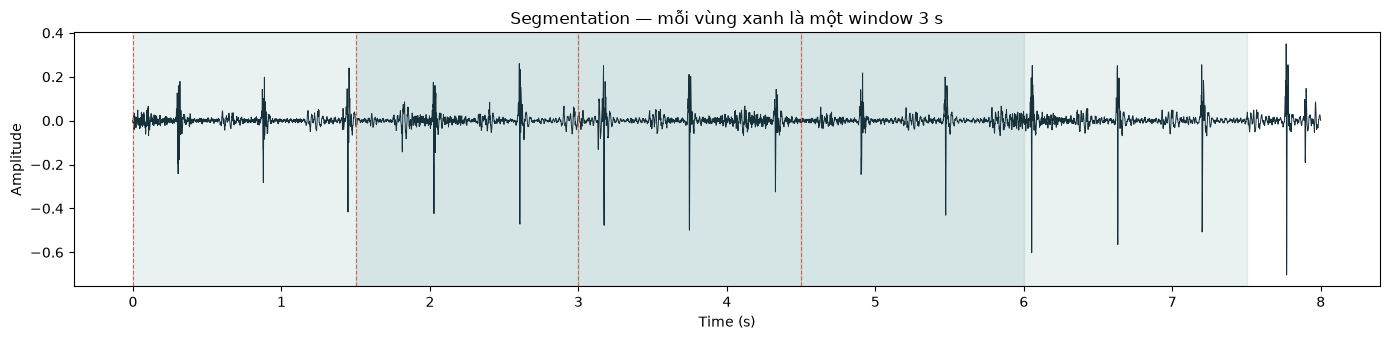

Patient table shape: (100, 3)


,patient_id,label,features
0,13918,Present,"[-2.281336855958216e-05, 0.03459643945097923, ..."
1,14241,Present,"[1.9042602161789546e-07, 0.022286314517259598,..."
2,14998,Absent,"[-1.9238902950746706e-06, 0.043120741844177246..."


In [26]:
# Visualization B — segmentation 3 giây, hop 1,5 giây
segments = segment_signal(
    filtered,
    fs_target,
    seconds=3.0,
    hop_seconds=1.5,
)
feature_config = {
    key: value
    for key, value in BASE_CONFIG["features"].items()
    if key != "mode"
}
hybrid_vector = feature_vector(
    segments[0],
    fs_target,
    mode="hybrid",
    **feature_config,
)
print("Samples per window:", 3 * fs_target)
print("Windows in sample recording:", len(segments))
print("Hybrid feature vector length:", len(hybrid_vector))
print("First 10 features:", hybrid_vector[:10])

view_n = min(len(filtered), 8 * fs_target)
t = np.arange(view_n) / fs_target
plt.figure(figsize=(14, 3.5))
plt.plot(t, filtered[:view_n], color="#17313B", lw=.7)
for start in np.arange(0, max(0, view_n / fs_target - 3), 1.5):
    plt.axvspan(start, start + 3.0, color="#2B7A78", alpha=.10)
    plt.axvline(start, color="#D96445", ls="--", lw=.8)
plt.title("Segmentation — mỗi vùng xanh là một window 3 s")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()
print("Patient table shape:", baseline_table.shape)
display(baseline_table.head(3))

,count
Train patients,70
Validation patients,14
Test patients,16


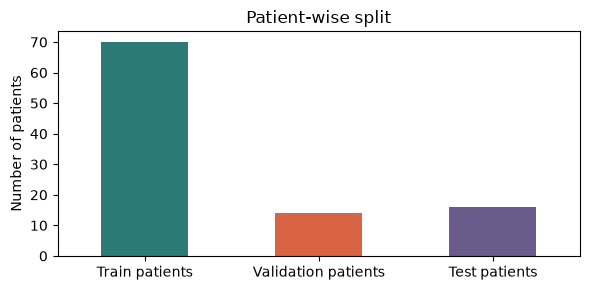

In [27]:
# Visualization C — split theo patient, không split recording ngẫu nhiên
train_ids, validation_ids, test_ids = patient_split(
    baseline_table,
    seed=baseline_cfg["split"]["seed"],
)
split_sizes = pd.Series({
    "Train patients": len(train_ids),
    "Validation patients": len(validation_ids),
    "Test patients": len(test_ids),
})
display(split_sizes.to_frame("count"))
split_sizes.plot.bar(
    figsize=(6, 3),
    color=["#2B7A78", "#D96445", "#6A5C8A"],
    title="Patient-wise split",
)
plt.ylabel("Number of patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
# 6) Full matrix 3 filters × 4 feature modes × 2 classifiers
matrix_rows = []
if RUN_MATRIX:
    for model_name in ['svm', 'mlp']:
        for filter_name in ['none', 'butterworth', 'fir']:
            for feature_name in ['psd', 'mfcc', 'stft', 'hybrid']:
                cfg = copy.deepcopy(BASE_CONFIG)
                cfg['model']['kind'] = model_name
                cfg['dsp']['filter'] = filter_name
                cfg['features']['mode'] = feature_name
                run_name = f'{model_name}_{filter_name}_{feature_name}'
                table = make_patient_table(DATA_DIR, cfg, MAX_PATIENTS)
                result = train_evaluate(table, cfg, OUTPUT_DIR / 'runs' / run_name)
                matrix_rows.append({'model': model_name, 'filter': filter_name, 'features': feature_name, **result})
                print(run_name, 'Macro-F1=', round(result['f1_macro'], 4))
    matrix_df = pd.DataFrame(matrix_rows).sort_values('f1_macro', ascending=False)
    matrix_df.to_csv(OUTPUT_DIR / 'full_matrix.csv', index=False)
    display(matrix_df[['model','filter','features','f1_macro','balanced_accuracy','accuracy']].head(10))
else:
    matrix_df = pd.DataFrame()

## Step 6 — Đọc kết quả matrix

Baseline là Butterworth + Hybrid + SVM. Split theo patient để model không nhìn thấy recording khác của cùng một bệnh nhân ở test.

In [29]:
# 7) Matrix heatmap
if not matrix_df.empty:
    heat = matrix_df.pivot_table(index=['model','filter'], columns='features', values='f1_macro')
    plt.figure(figsize=(10, 5))
    sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1)
    plt.title('DSP ablation matrix — Macro-F1'); plt.tight_layout(); plt.show()

## Step 7 — Robustness

So sánh 3 filter × 4 feature modes × 2 classifiers để đo ảnh hưởng của từng khối DSP.

In [30]:
# 8) Robustness đúng theo run_robustness.py của project
robustness_rows = []
if RUN_ROBUSTNESS:
    experiments = []
    for fs in [1000, 2000, 4000]: experiments.append((f'sampling_{fs}hz', fs, 16, False, 'white', 10))
    for bits in [8, 12, 16]: experiments.append((f'quantization_{bits}bit', 1000, bits, False, 'white', 10))
    for kind, snr in [('white',20), ('white',10), ('pink',10), ('impulse',10)]: experiments.append((f'noise_{kind}_{snr}db', 1000, 16, True, kind, snr))
    for name, fs, bits, enabled, kind, snr in experiments:
        cfg = copy.deepcopy(BASE_CONFIG)
        cfg['model']['kind'] = 'svm'; cfg['dsp']['filter'] = 'butterworth'; cfg['features']['mode'] = 'hybrid'
        cfg['dsp']['target_fs'] = fs; cfg['dsp']['quantization_bits'] = bits
        cfg['noise'] = {'enabled': enabled, 'kind': kind, 'snr_db': snr}
        table = make_patient_table(DATA_DIR, cfg, MAX_PATIENTS)
        result = train_evaluate(table, cfg, OUTPUT_DIR / 'robustness_runs' / name)
        robustness_rows.append({'experiment': name, 'target_fs': fs, 'quantization_bits': bits, 'noise_kind': kind if enabled else 'none', 'snr_db': snr if enabled else None, **result})
        print(name, 'Macro-F1=', round(result['f1_macro'], 4))
    robustness_df = pd.DataFrame(robustness_rows)
    robustness_df.to_csv(OUTPUT_DIR / 'robustness.csv', index=False)
    display(robustness_df[['experiment','f1_macro','balanced_accuracy']])
else:
    robustness_df = pd.DataFrame()

## Step 8 — Đọc robustness plot

Mỗi ô là Macro-F1 trên các test patients. Ô cao hơn là cấu hình tạo ra biểu diễn tín hiệu tốt hơn cho bài toán Absent/Present.

In [31]:
# 9) Robustness plot
if not robustness_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, prefix, title in zip(axes, ['sampling_', 'quantization_', 'noise_'], ['Sampling', 'Quantization', 'Noise']):
        part = robustness_df[robustness_df.experiment.str.startswith(prefix)]
        sns.barplot(data=part, x='experiment', y='f1_macro', ax=ax, color='#2B7A78')
        ax.set_title(title); ax.set_ylim(0, 1); ax.tick_params(axis='x', rotation=35); ax.set_xlabel(''); ax.set_ylabel('Macro-F1')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'robustness.png', dpi=160); plt.show()

## Step 9 — Robustness

Cố ý thay sampling rate, bit depth và loại noise để xem chất lượng feature/model suy giảm thế nào.

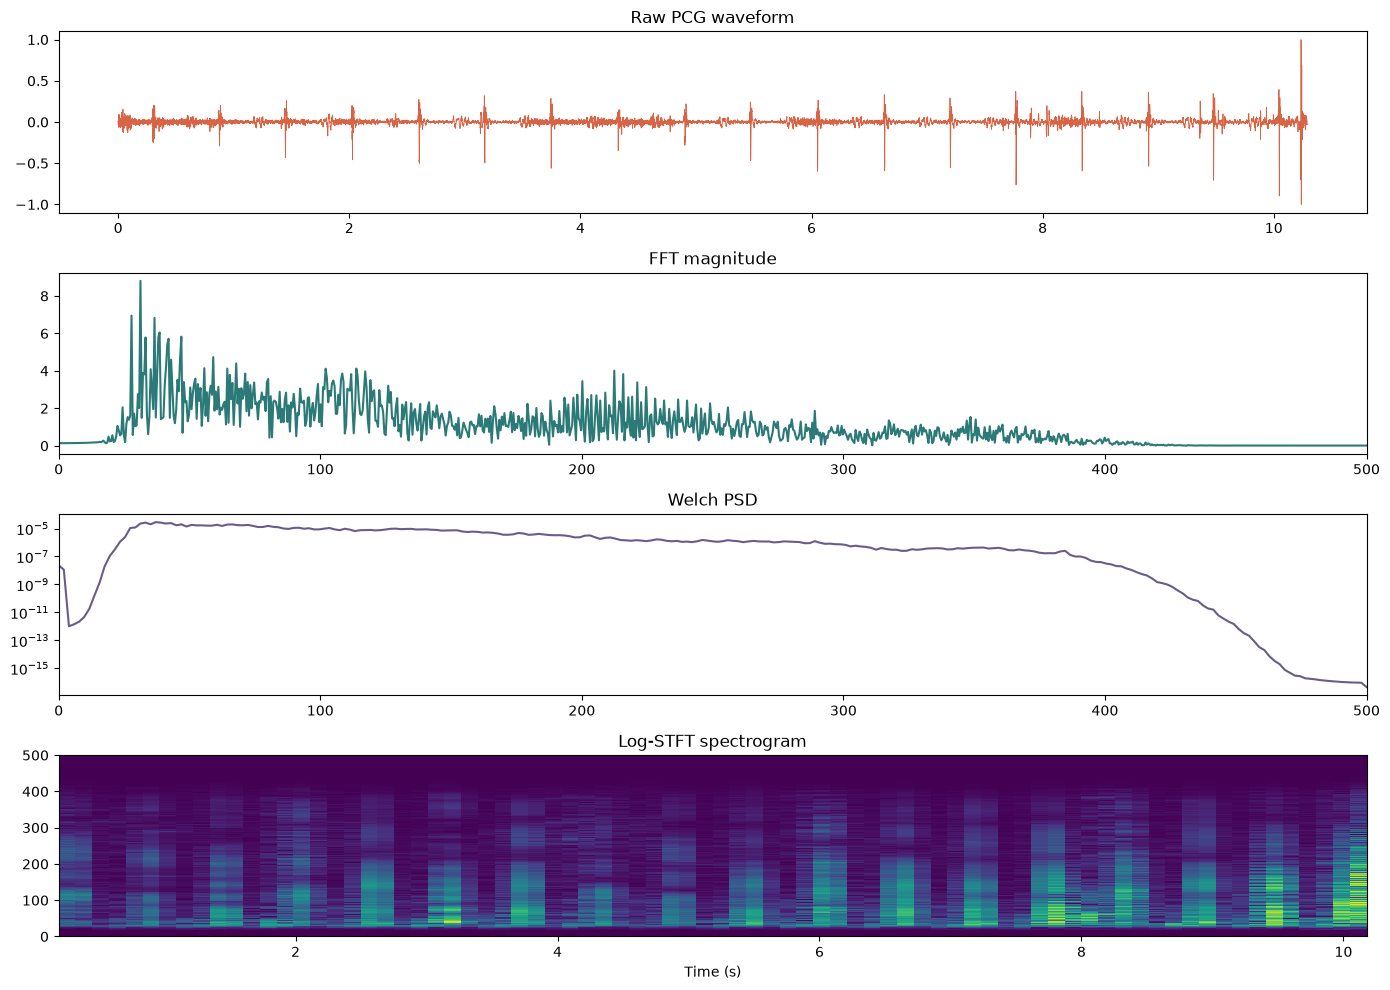

Sample: 13918_AV.wav | source fs: 4000


In [32]:
# 10) Signal report bằng đúng hàm DSP của project
sample_wav = Path(manifest.iloc[0].wav_path)
fs_raw, raw = load_wav(sample_wav)
fs_target = 1000
processed = resample_signal(raw, fs_raw, fs_target)
processed = quantize(processed, 16)
processed = apply_filter(processed, design_filter(fs_target, 'butterworth'))
freqs, times, matrix = stft_matrix(processed, fs_target)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(np.arange(len(raw))/fs_raw, raw, lw=.6, color='#D96445'); axes[0].set_title('Raw PCG waveform')
axes[1].plot(np.fft.rfftfreq(2048, 1/fs_target), np.abs(np.fft.rfft(processed, n=2048)), color='#2B7A78'); axes[1].set_title('FFT magnitude'); axes[1].set_xlim(0,500)
from scipy import signal
f_psd, p_psd = signal.welch(processed, fs=fs_target, nperseg=min(512,len(processed))); axes[2].semilogy(f_psd,p_psd,color='#6A5C8A'); axes[2].set_title('Welch PSD'); axes[2].set_xlim(0,500)
axes[3].pcolormesh(times, freqs, matrix, shading='auto', cmap='viridis'); axes[3].set_title('Log-STFT spectrogram'); axes[3].set_ylim(0,500); axes[3].set_xlabel('Time (s)')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'signal_report.png', dpi=160); plt.show()
print('Sample:', sample_wav.name, '| source fs:', fs_raw)

## Step 10 — Signal report

Waveform, FFT, PSD và STFT cho thấy cùng một tín hiệu được nhìn ở miền thời gian, miền tần số và time-frequency.

In [33]:
# 11) Chọn model tốt nhất và inference WAV mới
if not matrix_df.empty:
    best = matrix_df.iloc[0]
    best_cfg = copy.deepcopy(BASE_CONFIG)
    best_cfg['model']['kind'] = best['model']; best_cfg['dsp']['filter'] = best['filter']; best_cfg['features']['mode'] = best['features']
    best_dir = OUTPUT_DIR / 'best_model'
    best_table = make_patient_table(DATA_DIR, best_cfg, MAX_PATIENTS)
    best_result = train_evaluate(best_table, best_cfg, best_dir)
    model_bundle = load_model_bundle(best_dir / 'model.joblib')
    print('Best config:', best[['model','filter','features']].to_dict())
    print('Best result:', json.dumps(best_result, indent=2, default=float))
elif RUN_TRAINING:
    model_bundle = load_model_bundle(OUTPUT_DIR / 'baseline_model' / 'model.joblib')
else:
    model_bundle = None
    print('RUN_TRAINING=False → inference skipped; flow-only notebook completed.')

# Đổi path này thành file WAV muốn test.
def predict_wav(wav_path):
    if model_bundle is None:
        raise RuntimeError('No model bundle. Set RUN_TRAINING=True and run the training cell first.')
    model, model_config = model_bundle
    result = analyze_recording(wav_path, model, model_config)
    return {'label': result['label'], 'probabilities': result['probabilities']}

# Ví dụ: predict_wav('/content/my_recording.wav')
print('All outputs saved under:', OUTPUT_DIR)

RUN_TRAINING=False → inference skipped; flow-only notebook completed.
All outputs saved under: f:\2. Thạc sĩ\DSP\pcg_murmur_dsp\artifacts\notebook_flow


## Step 11 — Inference

Model tốt nhất được lưu cùng config preprocessing. WAV mới phải đi qua đúng config đó trước khi dự đoán.

## Lưu ý khi chạy

- `FAST_MODE = True` dùng 100 bệnh nhân để kiểm tra pipeline.
- `FAST_MODE = False` chạy full cohort 1.568 bệnh nhân.
- `RUN_MATRIX` và `RUN_ROBUSTNESS` có thể tắt riêng nếu Colab hết thời gian.
- Kết quả được lưu trong `/content/pcg_dsp_outputs`.
- Đây là research prototype, không phải công cụ chẩn đoán lâm sàng.